# Loan Approval Prediction
## ML Workflow (Preprocessing, Feature Selection, Splitting, Evaluation)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Exploaratory Data Analysis

EXPLORATORY DATA ANALYSIS

Target Column : loan_status

Dataset Shape
(4269, 13)

Column Names
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Data Types
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------    

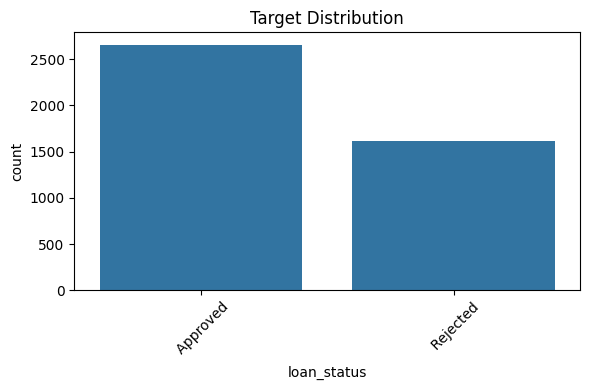


Distribution Analysis


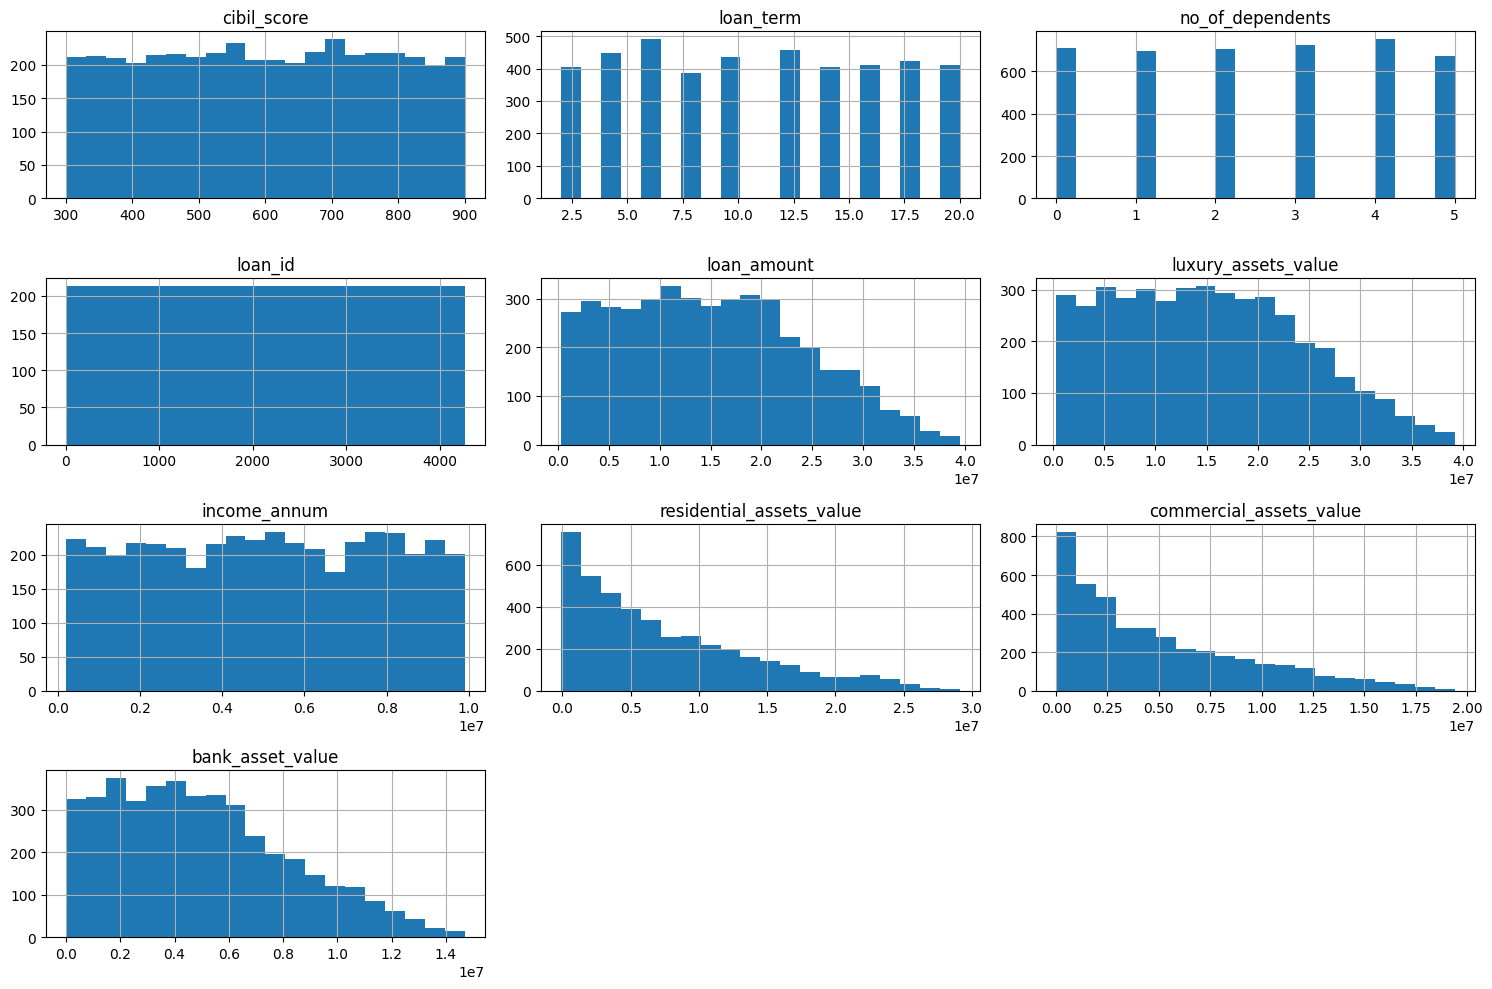


Outlier Detection


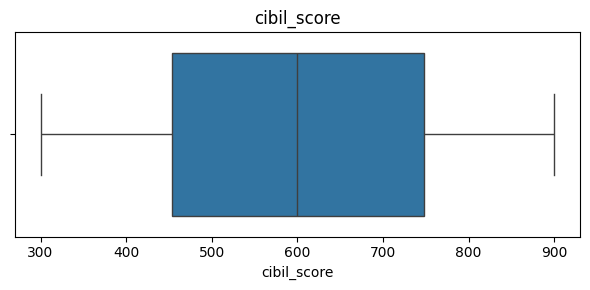

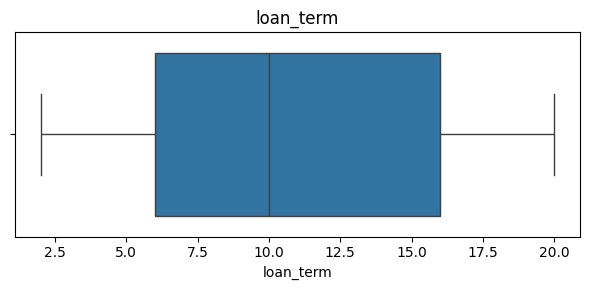

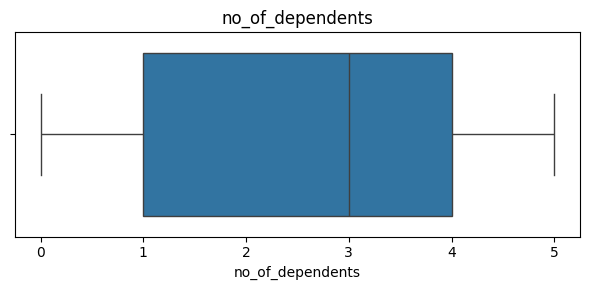

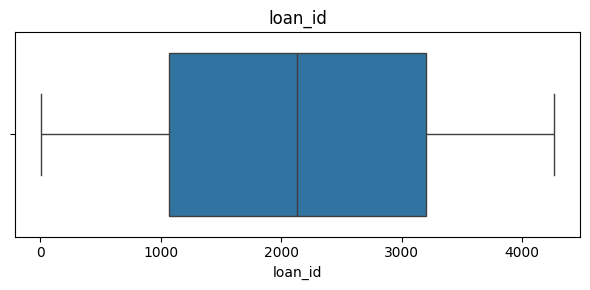

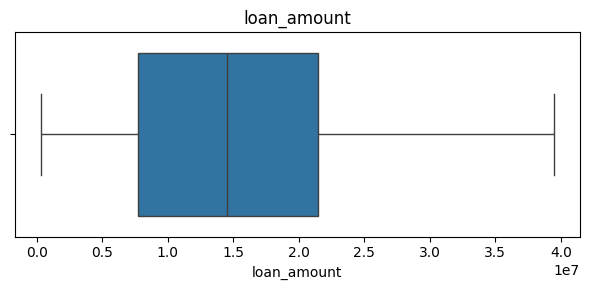

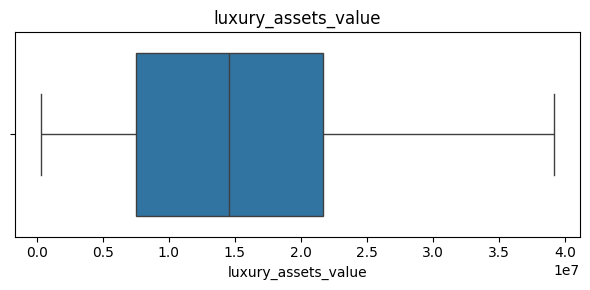

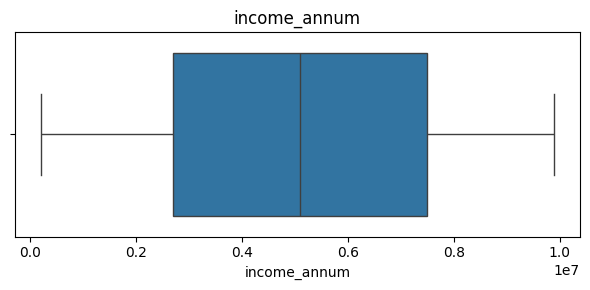

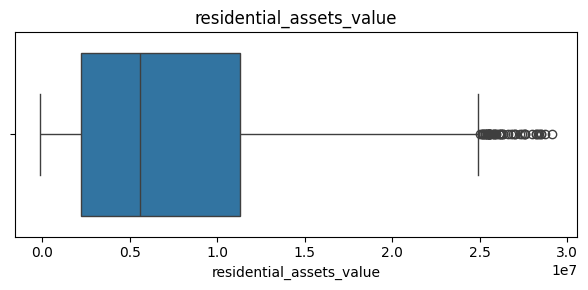

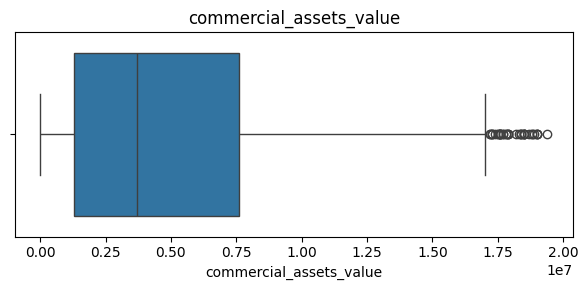

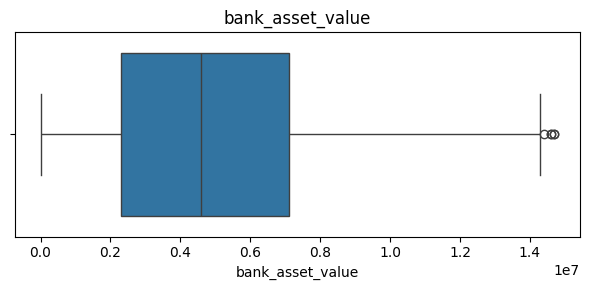


Correlation Heatmap


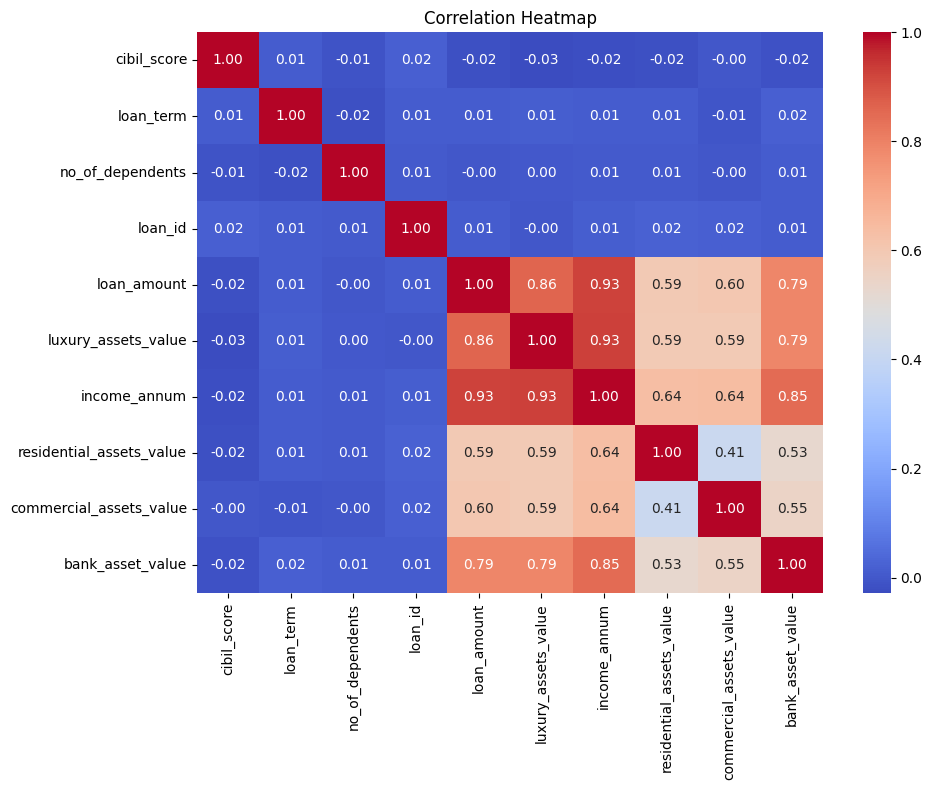


Pair Plot


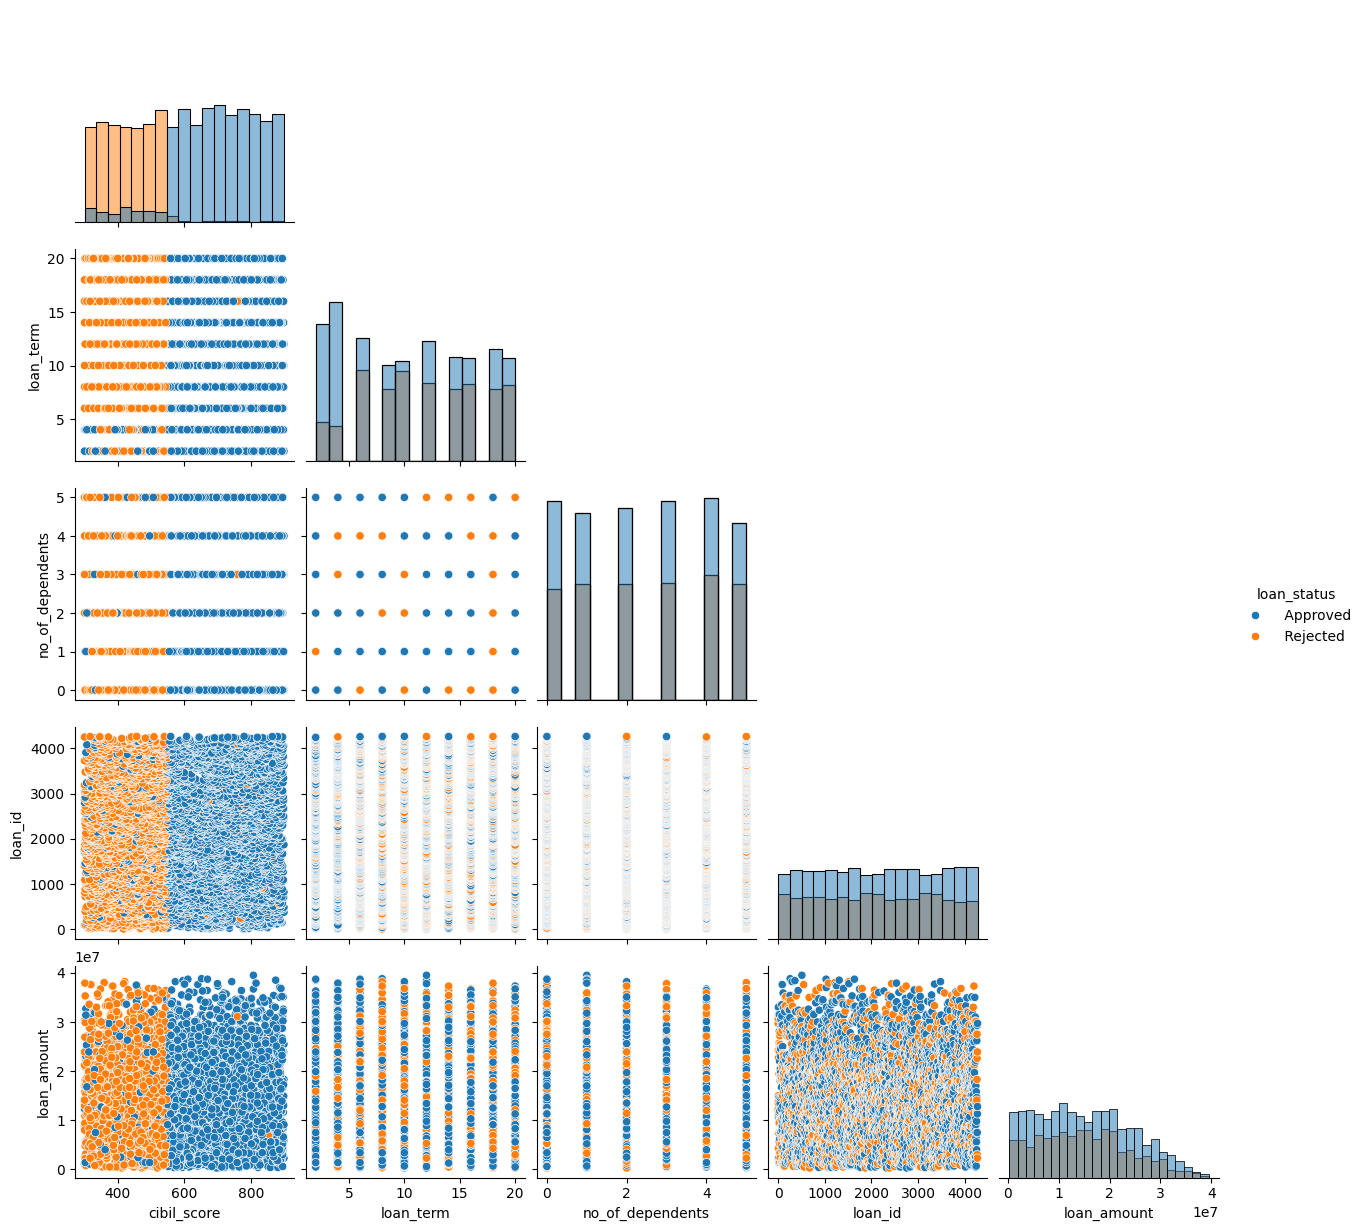


Relationship with Target


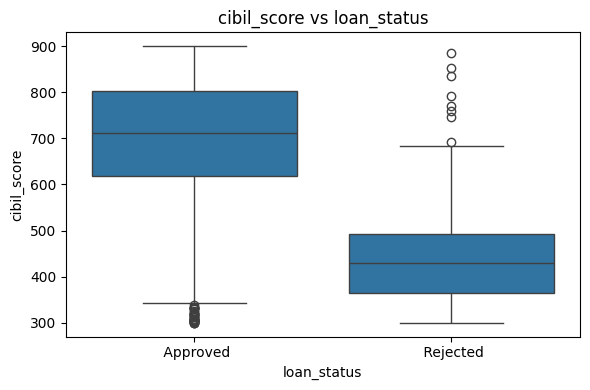

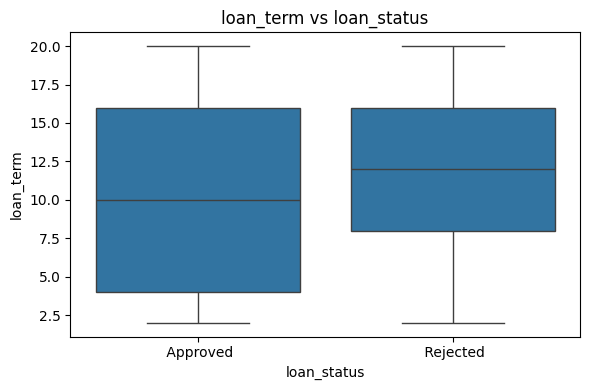

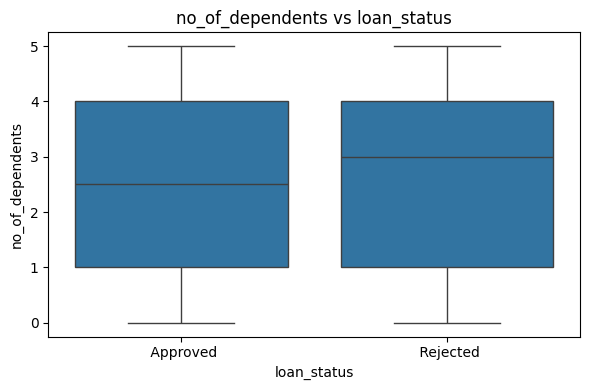

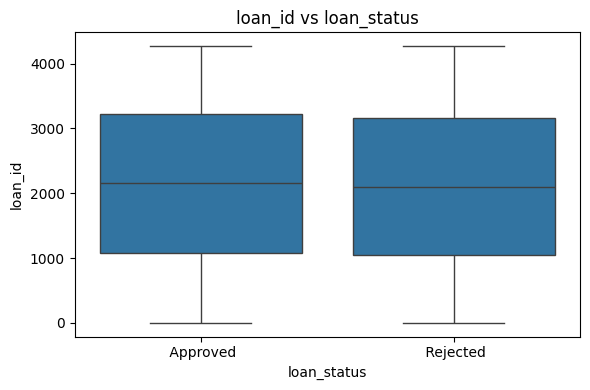

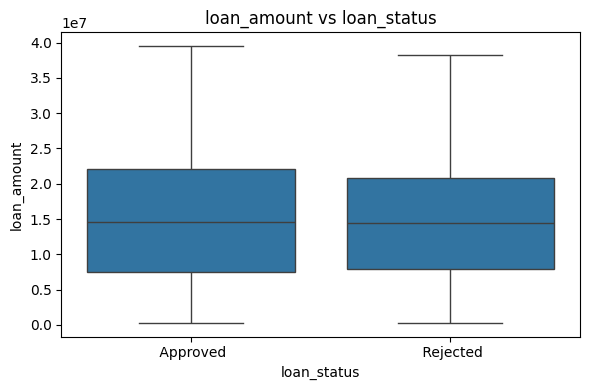

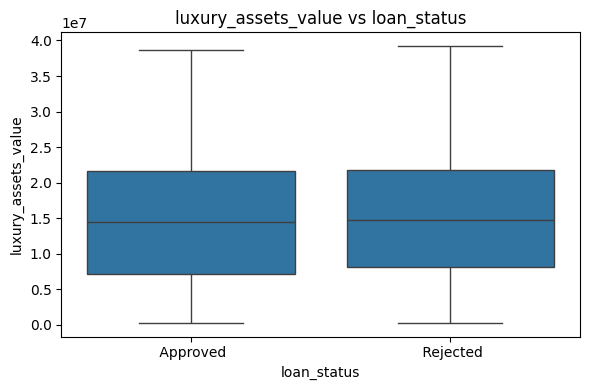

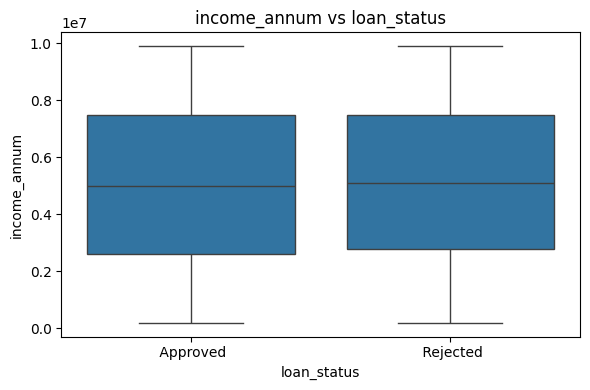

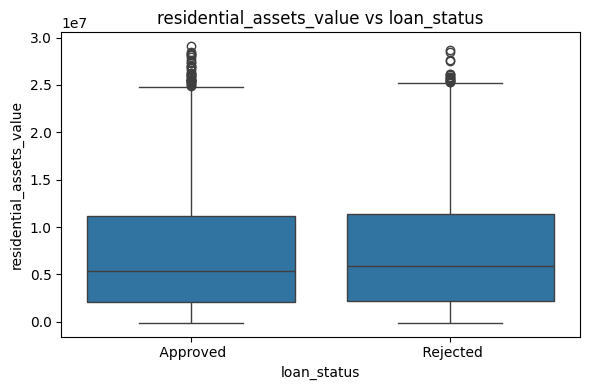

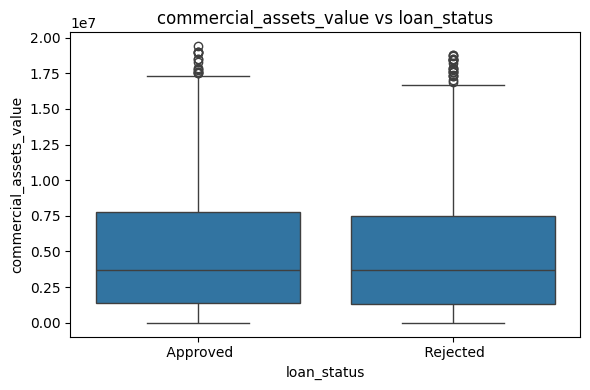

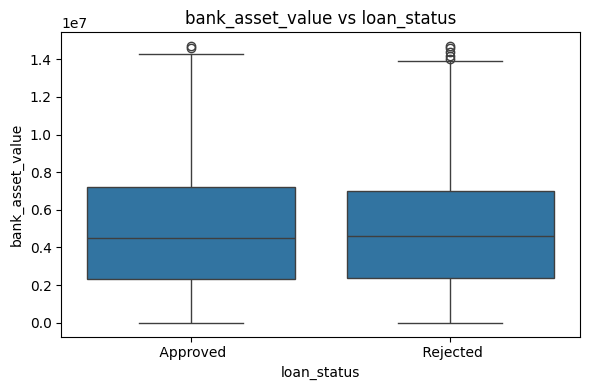


Categorical Analysis


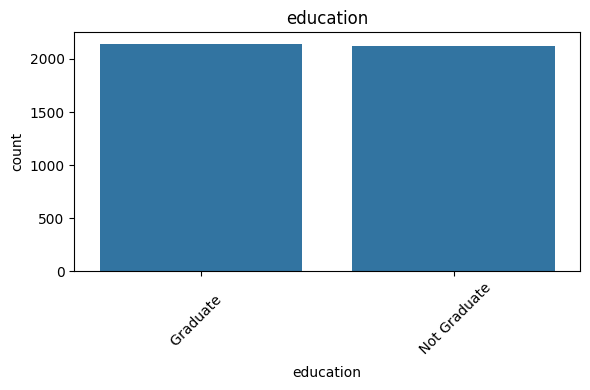

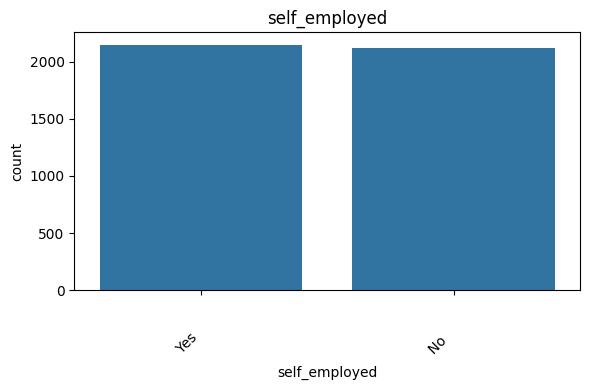

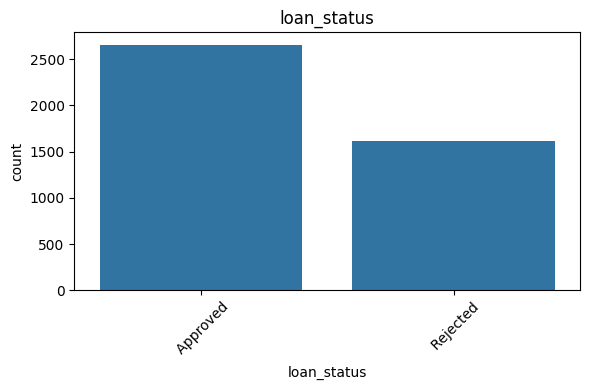


Skewness
loan_id                     0.000000
no_of_dependents           -0.017971
income_annum               -0.012814
loan_amount                 0.308724
loan_term                   0.036359
cibil_score                -0.009039
residential_assets_value    0.978451
commercial_assets_value     0.957791
luxury_assets_value         0.322208
bank_asset_value            0.560725
dtype: float64

Kurtosis
loan_id                    -1.200000
no_of_dependents           -1.256992
income_annum               -1.182729
loan_amount                -0.743680
loan_term                  -1.220853
cibil_score                -1.185670
residential_assets_value    0.184738
commercial_assets_value     0.100813
luxury_assets_value        -0.738056
bank_asset_value           -0.397277
dtype: float64

EDA COMPLETED SUCCESSFULLY


In [2]:

def _get_important_features(df, target, numeric, max_features):
    """Automatically select important numerical features."""
    numeric = list(numeric)

    if target in numeric:
        try:
            corr = (
                df[numeric]
                .corr()[target]
                .abs()
                .sort_values(ascending=False)
            )
            feats = corr.index.drop(target).tolist()
            return feats[:max_features]
        except Exception:
            pass

    try:
        X = df[numeric].drop(columns=[target], errors="ignore")
        y = df[target]

        if X.shape[1] > 0:
            scores, _ = f_classif(X.fillna(X.median()), y)
            ranking = (
                pd.Series(scores, index=X.columns)
                .sort_values(ascending=False)
            )
            return ranking.head(max_features).index.tolist()

    except Exception:
        pass

    return [c for c in numeric if c != target][:max_features]


def perform_eda(
    df,
    target=None,
    max_features=10,
    pairplot_features=5,
    max_categories=20
):
    """
    Universal EDA Function.

    Parameters
    ----------
    df : pandas.DataFrame
    target : str or None
        Target column name. If None, last column is assumed.
    max_features : int
        Maximum numerical features for plots.
    pairplot_features : int
        Maximum features used in pairplot.
    max_categories : int
        Maximum unique categories for countplots.
    """

    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    if target is None:
        target = df.columns[-1]

    print(f"\nTarget Column : {target}")

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nDataset Info")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Value Percentage")
    print((df.isnull().sum() / len(df)) * 100)

    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    print("\nNumerical Columns")
    print(numeric)

    print("\nCategorical Columns")
    print(categorical)

    important = _get_important_features(
        df,
        target,
        numeric,
        max_features
    )

    print("\nImportant Features Selected")
    print(important)

    # ---------------------------
    # Class Distribution
    # ---------------------------
    if target in categorical:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[target])
        plt.title("Target Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Histograms
    # ---------------------------
    if important:
        print("\nDistribution Analysis")
        df[important].hist(
            figsize=(15,10),
            bins=20
        )
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Boxplots
    # ---------------------------
    if important:
        print("\nOutlier Detection")

        for col in important:
            plt.figure(figsize=(6,3))
            sns.boxplot(x=df[col])
            plt.title(col)
            plt.tight_layout()
            plt.show()

    # ---------------------------
    # Heatmap
    # ---------------------------
    if len(important) > 1:
        print("\nCorrelation Heatmap")

        plt.figure(figsize=(10,8))

        sns.heatmap(
            df[important].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Pairplot
    # ---------------------------
    if len(important) >= 2:

        pair_cols = important[:pairplot_features]

        if target not in pair_cols:
            pair_cols.append(target)

        print("\nPair Plot")

        if target in categorical:

            sns.pairplot(
                df[pair_cols],
                hue=target,
                diag_kind="hist",
                corner=True
            )

        else:

            sns.pairplot(
                df[pair_cols],
                diag_kind="hist",
                corner=True
            )

        plt.show()

    # ---------------------------
    # Target Relationship
    # ---------------------------
    if target in categorical:

        print("\nRelationship with Target")

        for col in important:

            plt.figure(figsize=(6,4))

            sns.boxplot(
                x=df[target],
                y=df[col]
            )

            plt.title(f"{col} vs {target}")

            plt.tight_layout()

            plt.show()

    # ---------------------------
    # Countplots
    # ---------------------------
    if categorical:

        print("\nCategorical Analysis")

        for col in categorical:

            if df[col].nunique() <= max_categories:

                plt.figure(figsize=(6,4))

                sns.countplot(
                    x=df[col],
                    order=df[col].value_counts().index
                )

                plt.xticks(rotation=45)

                plt.title(col)

                plt.tight_layout()

                plt.show()

            else:
                print(f"Skipping '{col}' (>{max_categories} unique categories).")

    # ---------------------------
    # Skewness
    # ---------------------------
    if numeric:
        print("\nSkewness")
        print(df[numeric].skew())

        print("\nKurtosis")
        print(df[numeric].kurt())

    print("\n" + "=" * 70)
    print("EDA COMPLETED SUCCESSFULLY")
    print("=" * 70)

perform_eda(df)    


## Data Preprocessing

In [3]:
def preprocess_data(df):

      # Remove extra spaces from column names
    df.columns = df.columns.str.strip()


    df = df.copy()

    # Missing Values
    print("Missing Values")
    print(df.isnull().sum())

    # Remove Duplicates
    df.drop_duplicates(inplace=True)

    # Drop Irrelevant Column
    if "loan_id" in df.columns:
        df.drop("loan_id", axis=1, inplace=True)

    # Encode Categorical Columns
    le = LabelEncoder()

    for col in df.select_dtypes(include="object").columns:
        df[col] = le.fit_transform(df[col])

    # Separate Features and Target
    X = df.drop("loan_status", axis=1)
    y = df["loan_status"]

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    print("\nPreprocessing Completed")

    return X, X_scaled, y

X_original, X_scaled, y = preprocess_data(df)


Missing Values
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Preprocessing Completed


## Feature Selection

In [4]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def feature_selection(X_original, X_scaled, y):

    # Convert data to non-negative for Chi-Square
    minmax = MinMaxScaler()
    X_chi = pd.DataFrame(
        minmax.fit_transform(X_original),
        columns=X_original.columns
    )

    print("="*50)
    print("Chi-Square Scores")
    print("="*50)

    chi = SelectKBest(score_func=chi2, k="all")
    chi.fit(X_chi, y)

    chi_scores = pd.DataFrame({
        "Feature": X_chi.columns,
        "Chi-Square Score": chi.scores_
    })

    print(chi_scores.sort_values(by="Chi-Square Score", ascending=False))


    print("\n" + "="*50)
    print("ANOVA Scores")
    print("="*50)

    anova = SelectKBest(score_func=f_classif, k="all")
    anova.fit(X_scaled, y)

    anova_scores = pd.DataFrame({
        "Feature": X_scaled.columns,
        "ANOVA Score": anova.scores_
    })

    print(anova_scores.sort_values(by="ANOVA Score", ascending=False))


    print("\n" + "="*50)
    print("Top Selected Features")
    print("="*50)

    selector = SelectKBest(score_func=f_classif, k=5)

    X_selected = selector.fit_transform(X_scaled, y)

    selected_features = X_scaled.columns[selector.get_support()]

    print(selected_features.tolist())

    X_selected = pd.DataFrame(
        X_selected,
        columns=selected_features
    )

    return X_selected


X_selected = feature_selection(X_original, X_scaled, y)

Chi-Square Scores
                     Feature  Chi-Square Score
6                cibil_score        418.637526
5                  loan_term         11.094830
0           no_of_dependents          0.322398
7   residential_assets_value          0.168504
3               income_annum          0.164588
4                loan_amount          0.156561
9        luxury_assets_value          0.146679
8    commercial_assets_value          0.057941
1                  education          0.051854
10          bank_asset_value          0.028317
2              self_employed          0.000251

ANOVA Scores
                     Feature  ANOVA Score
6                cibil_score  6235.054591
5                  loan_term    55.225458
0           no_of_dependents     1.400600
4                loan_amount     1.113176
9        luxury_assets_value     1.020728
3               income_annum     0.984669
7   residential_assets_value     0.880877
8    commercial_assets_value     0.290152
10          bank_asset_val

## Data Splitting

In [5]:
def split_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print("Training Shape :", X_train.shape)
    print("Testing Shape :", X_test.shape)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X_selected, y)


Training Shape : (3415, 5)
Testing Shape : (854, 5)


## Model Training

In [6]:
model = KNeighborsClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## Performance Evaluation

Accuracy : 0.9297423887587822

Confusion Matrix
[[504  32]
 [ 28 290]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       536
           1       0.90      0.91      0.91       318

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



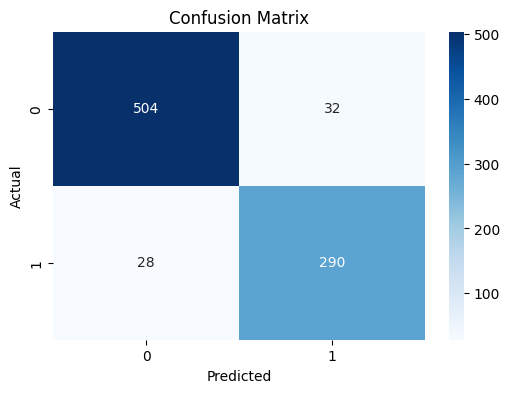

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
